# Cross-species pathway inference in PlantMetWiki
## Case study: capsaicin biosynthesis in *Capsicum*

This notebook explores the capsaicin biosynthesis pathway (PC629) to illustrate how
PlantMetWiki can be used to:
1. Identify which *Capsicum* species are annotated in the knowledge graph
2. Compare annotation coverage across species within the same pathway
3. Use shared metabolites and reactions to infer annotation gaps (cross-species inference)
4. Answer the question: *Can the capsaicin pathway be reconstructed across Capsicum species
   by integrating annotations from related species that share substrates, products, and reactions?*

---

## How to run

**Step 1 — Start Virtuoso** (the RDF triplestore):
```bash
# From the Snorql-UI repository
cd ../Snorql-UI
docker compose up -d virtuoso
# Wait ~30 seconds, then check: http://localhost:8890/sparql
```

**Step 2 — Load the PlantMetWiki graphs** (if not already loaded):
```bash
# From the Snorql-UI repo
bash scripts/load-graphs/load-all.sh
```

**Step 3 — Run this notebook**:
```bash
conda activate plantmetwiki-rdf
jupyter notebook notebooks/cross_species_capsicum.ipynb
```

---

## Named graphs used

| Named graph | Content |
|---|---|
| `graph/pathways` | Core WikiPathways RDF: `wp:Pathway`, `wp:GeneProduct`, `wp:Protein`, `wp:Metabolite`, `wp:Conversion` |
| `graph/gpml-taxonomy-extra` | Per-DataNode species annotations (`wp:organism ncbi:XXXXX`) |
| `graph/ncbitaxon` | OBO Foundry NCBITaxon ontology for label resolution (`rdfs:label`) |

**SPARQL endpoint:** `http://localhost:8890/sparql`

---

## SPARQL endpoint

You can run every query in this notebook against **either** endpoint:

| Mode | URL | When to use |
|------|-----|-------------|
| **Public** (no setup needed) | `https://plantmetwiki.bioinformatics.nl/sparql` | Quickest way to get started; no local installation required |
| **Local Virtuoso** (full data, fast) | `http://localhost:8890/sparql` | Required for the figures notebook (large aggregations); needs Docker |

To switch, change the `ENDPOINT` variable in the setup cell below.


---
## Setup

In [1]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'font.family': 'sans-serif',
                     'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans']})

# ── Choose endpoint ──────────────────────────────────────────────────────────
PUBLIC_ENDPOINT = 'https://plantmetwiki.bioinformatics.nl/sparql'
LOCAL_ENDPOINT  = 'http://localhost:8890/sparql'

# Switch between public and local by changing this line:
ENDPOINT = LOCAL_ENDPOINT   # or: PUBLIC_ENDPOINT

G_PW   = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/pathways'
G_TAX  = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/gpml-taxonomy-extra'
G_NCBI = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/ncbitaxon'
WP     = 'http://vocabularies.wikipathways.org/wp#'

PREFIXES = """
PREFIX wp:      <http://vocabularies.wikipathways.org/wp#>
PREFIX dc:      <http://purl.org/dc/elements/1.1/>
PREFIX dcterms: <http://purl.org/dc/terms/>
PREFIX rdfs:    <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ncbi:    <http://purl.obolibrary.org/obo/NCBITaxon_>
PREFIX cito:    <http://purl.org/spar/cito/>
"""

def sparql(query, timeout=120):
    sw = SPARQLWrapper(ENDPOINT)
    sw.setReturnFormat(JSON)
    sw.setTimeout(timeout)
    sw.setQuery(PREFIXES + query)
    rows = sw.query().convert()['results']['bindings']
    return pd.DataFrame([{k: v['value'] for k, v in r.items()} for r in rows])

def ensure_col(df, col, default=''):
    """Add column with default value if SPARQL OPTIONAL returned no bindings."""
    if col not in df.columns:
        df[col] = default
    return df

print('Ready. Endpoint:', ENDPOINT)


Ready. Endpoint: http://localhost:8890/sparql


---
## Step 1 — Which *Capsicum* species are in PlantMetWiki?

We first ask the knowledge graph for all species whose name contains "Capsicum".
Species labels are resolved from `graph/ncbitaxon` (OBO Foundry NCBITaxon ontology).


In [2]:
capsicum_species = sparql(f"""
SELECT DISTINCT ?taxon ?name (COUNT(DISTINCT ?node) AS ?annotated_nodes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?name . FILTER(CONTAINS(LCASE(?name), "capsicum")) }}
}}
GROUP BY ?taxon ?name
ORDER BY DESC(?annotated_nodes)
""")

capsicum_species['ncbi_id'] = capsicum_species['taxon'].str.extract(r'NCBITaxon_(\d+)')
capsicum_species['annotated_nodes'] = capsicum_species['annotated_nodes'].astype(int)
print(capsicum_species[['ncbi_id','name','annotated_nodes']].to_string(index=False))


ncbi_id                name  annotated_nodes
   4072     Capsicum annuum               71
  80379   Capsicum chinense               22
   4071            Capsicum                7
   4073 Capsicum frutescens                4


> **Observation:** Four *Capsicum* entries are present: the genus-level node (*Capsicum*, NCBITaxon:4071)
> and three species — *C. annuum* (4072), *C. chinense* (80379), and *C. frutescens* (4073).
> *Capsicum annuum* has the most annotated DataNodes overall, reflecting its status as the primary
> model pepper species in PlantCyc.


---
## Step 2 — How many pathways does each *Capsicum* species cover?

Each pathway a species "covers" means it has at least one directly annotated gene or
enzyme node (`wp:organism`) that is `dcterms:isPartOf` that pathway.


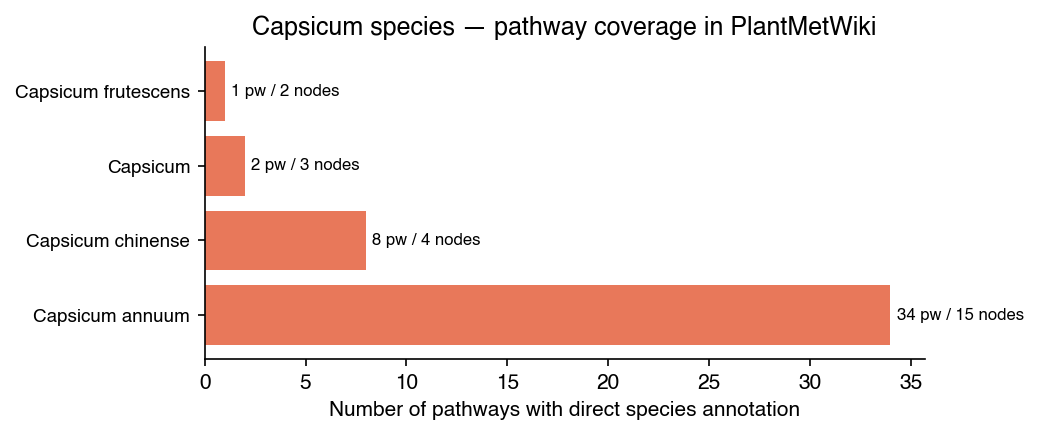

ncbi_id                name  pathways  annotated_nodes
   4072     Capsicum annuum        34               15
  80379   Capsicum chinense         8                4
   4071            Capsicum         2                3
   4073 Capsicum frutescens         1                2


In [3]:
capsicum_pathways = sparql(f"""
SELECT ?name ?taxon (COUNT(DISTINCT ?pw) AS ?pathways)
       (COUNT(DISTINCT ?node) AS ?annotated_nodes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node dcterms:isPartOf ?pw . ?pw a wp:Pathway }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?name . FILTER(CONTAINS(LCASE(?name), "capsicum")) }}
}}
GROUP BY ?name ?taxon
ORDER BY DESC(?pathways)
""")

capsicum_pathways['ncbi_id']   = capsicum_pathways['taxon'].str.extract(r'NCBITaxon_(\d+)')
capsicum_pathways['pathways']  = capsicum_pathways['pathways'].astype(int)
capsicum_pathways['annotated_nodes'] = capsicum_pathways['annotated_nodes'].astype(int)

fig, ax = plt.subplots(figsize=(7, 3))
y = np.arange(len(capsicum_pathways))
ax.barh(y, capsicum_pathways['pathways'], color='#e8785a')
ax.set_yticks(y)
ax.set_yticklabels(capsicum_pathways['name'], fontsize=9)
ax.set_xlabel('Number of pathways with direct species annotation')
ax.set_title('Capsicum species — pathway coverage in PlantMetWiki')
for i, (n, nodes) in enumerate(zip(capsicum_pathways['pathways'], capsicum_pathways['annotated_nodes'])):
    ax.text(n + 0.3, i, f'{n} pw / {nodes} nodes', va='center', fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print(capsicum_pathways[['ncbi_id','name','pathways','annotated_nodes']].to_string(index=False))


> **Observation:** *Capsicum annuum* (NCBITaxon:4072) dominates with 34 pathways, far exceeding
> *C. chinense* (8), the genus *Capsicum* (2), and *C. frutescens* (1). This mirrors the
> curation depth of CapsicumCyc vs other PlantCyc databases.


---
## Step 3 — The capsaicin biosynthesis pathway (PC629)

We retrieve the pathway title and count of each entity type to understand its structure.


In [4]:
PW629 = 'http://rdf-plantmetwiki.bioinformatics.nl/pathways/PC629_r17.0.0_20260520160610'

pw_info = sparql(f"""
SELECT ?title ?type (COUNT(DISTINCT ?e) AS ?n)
WHERE {{
  GRAPH <{G_PW}> {{
    <{PW629}> a wp:Pathway ; dc:title ?title .
    ?e dcterms:isPartOf <{PW629}> ; a ?type .
    FILTER(STRSTARTS(STR(?type), "{WP}"))
  }}
}}
GROUP BY ?title ?type
ORDER BY DESC(?n)
""")

pw_info['type_short'] = pw_info['type'].str.replace(WP, 'wp:', regex=False)
pw_info['n'] = pw_info['n'].astype(int)
title = pw_info['title'].iloc[0]
print(f'Pathway: {title}  ({PW629.split("/")[-1]})')
print()
print(pw_info[['type_short','n']].to_string(index=False))


Pathway: capsaicin biosynthesis  (PC629_r17.0.0_20260520160610)

                 type_short  n
             wp:Interaction 56
                wp:DataNode 51
     wp:DirectedInteraction 47
              wp:Metabolite 27
              wp:Conversion 19
                 wp:Protein 13
               wp:Catalysis 12
wp:TranscriptionTranslation 11
             wp:GeneProduct 11
    wp:PublicationReference  5
             wp:Stimulation  4
              wp:Inhibition  1


> **Pathway structure:** PC629 contains 27 metabolites (`wp:Metabolite`), 19 biochemical conversions
> (`wp:Conversion`), 13 enzyme nodes (`wp:Protein`), 11 gene product nodes (`wp:GeneProduct`),
> and 12 catalytic links (`wp:Catalysis`). Five literature references support the pathway.
>
> The `wp:Catalysis` edges link each enzyme to the conversion it catalyses — they are the
> key edges for cross-species inference.


---
## Step 4 — Which species are annotated in the capsaicin biosynthesis pathway?

This query counts annotated DataNodes per species **within PC629 only**.


In [5]:
PW629 = 'http://rdf-plantmetwiki.bioinformatics.nl/pathways/PC629_r17.0.0_20260520160610'

# Two simple queries — Virtuoso does not support CASE WHEN in SPARQL
nodes_all = sparql(f"""
SELECT ?name ?taxon (COUNT(DISTINCT ?node) AS ?total_nodes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node dcterms:isPartOf <{PW629}> }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?name }}
}}
GROUP BY ?name ?taxon
ORDER BY DESC(?total_nodes)
""")

genes_q = sparql(f"""
SELECT ?taxon (COUNT(DISTINCT ?node) AS ?genes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node a wp:GeneProduct ; dcterms:isPartOf <{PW629}> }}
}}
GROUP BY ?taxon
""")

enzymes_q = sparql(f"""
SELECT ?taxon (COUNT(DISTINCT ?node) AS ?enzymes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node a wp:Protein ; dcterms:isPartOf <{PW629}> }}
}}
GROUP BY ?taxon
""")

species_in_pw629 = (nodes_all
    .merge(genes_q,   on='taxon', how='left')
    .merge(enzymes_q, on='taxon', how='left'))
for c in ['total_nodes','genes','enzymes']:
    species_in_pw629[c] = pd.to_numeric(species_in_pw629[c], errors='coerce').fillna(0).astype(int)
species_in_pw629['ncbi_id'] = species_in_pw629['taxon'].str.extract(r'NCBITaxon_(\d+)')

print(species_in_pw629[['ncbi_id','name','genes','enzymes','total_nodes']].to_string(index=False))


ncbi_id                          name  genes  enzymes  total_nodes
   3702          Arabidopsis thaliana      3        3            6
  80379             Capsicum chinense      2        2            4
   4071                      Capsicum      1        2            3
   4006           Linum usitatissimum      1        1            2
   4073           Capsicum frutescens      1        1            2
  49390              Coffea canephora      1        1            2
  39947   Oryza sativa Japonica Group      1        1            2
   3879               Medicago sativa      1        1            2
   3544 Mesembryanthemum crystallinum      0        1            1


> **Key finding:** Nine species are represented in PC629.
> Notably, **`Capsicum annuum` (NCBITaxon:4072) is absent** — despite being the most
> pathway-rich *Capsicum* species overall (34 pathways), it has no directly annotated
> node in the capsaicin biosynthesis pathway.
>
> Annotations come from *C. chinense* (4 nodes), the genus *Capsicum* (3), *C. frutescens* (2),
> *Arabidopsis thaliana* (6), and four non-*Capsicum* species (*Linum*, *Coffea*, *Oryza*, *Medicago*,
> *Mesembryanthemum*) — reflecting phylogenetically shared enzyme families.


In [6]:
# Verify: direct count of C. annuum nodes in PC629
CAP_ANNUUM_IRI = 'http://purl.obolibrary.org/obo/NCBITaxon_4072'
CAP_GENUS_IRI  = 'http://purl.obolibrary.org/obo/NCBITaxon_4071'

check = sparql(f"""
SELECT ?taxon_label (COUNT(DISTINCT ?node) AS ?n)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon IN (<{CAP_ANNUUM_IRI}>, <{CAP_GENUS_IRI}>)) }}
  GRAPH <{G_PW}>  {{ ?node dcterms:isPartOf <{PW629}> }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?taxon_label }}
}}
GROUP BY ?taxon_label
""")
print("C. annuum and genus-level Capsicum annotations in PC629:")
print(check.to_string(index=False) if not check.empty else "  No C. annuum (ncbi:4072) annotations found.")

# What are the genus-level nodes?
genus_nodes = sparql(f"""
SELECT ?node ?type (STR(?id) AS ?identifier) (STR(?lbl) AS ?label)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism <{CAP_GENUS_IRI}> }}
  GRAPH <{G_PW}>  {{
    ?node dcterms:isPartOf <{PW629}> ; a ?type .
    FILTER(?type IN (wp:GeneProduct, wp:Protein))
    OPTIONAL {{ ?node dc:identifier ?id }}
    OPTIONAL {{ ?node rdfs:label    ?lbl }}
  }}
}}
""")
ensure_col(genus_nodes, 'identifier', '')
ensure_col(genus_nodes, 'label', '')
genus_nodes['type_short'] = genus_nodes['type'].str.replace(WP,'wp:',regex=False)
print()
print("Genus-level Capsicum nodes in PC629 (could be any Capsicum species):")
print(genus_nodes[['type_short','label','identifier']].to_string(index=False))


C. annuum and genus-level Capsicum annotations in PC629:
taxon_label n
   Capsicum 3

Genus-level Capsicum nodes in PC629 (could be any Capsicum species):
    type_short         label                                     identifier
    wp:Protein MONOMER-13534 https://identifiers.org/plantcyc/MONOMER-13534
wp:GeneProduct          HCHL       https://identifiers.org/plantcyc/G-10304
    wp:Protein  thioesterase https://identifiers.org/plantcyc/MONOMER-13531


> **Verifying the annotation gap:** The query above confirms that `Capsicum annuum` (NCBITaxon:4072)
> has **zero** directly annotated nodes in PC629.
>
> The three **genus-level** nodes (NCBITaxon:4071, annotated as *Capsicum* without species resolution)
> include MONOMER-13534, the HCHL gene (G-10304), and a thioesterase (MONOMER-13531).
> These represent PlantCyc entries where the enzyme was characterised in a *Capsicum* species
> but the exact species was not recorded — they may or may not be *C. annuum*.
>
> **Conclusion:** The annotation gap for *C. annuum* is **genuine**: no *C. annuum*-specific
> enzyme has been curated in the capsaicin biosynthesis pathway in PlantCyc 17.0.
> The genus-level nodes provide partial evidence but cannot be unambiguously assigned to any
> single species.


---
## Step 5 — What genes and enzymes are annotated per *Capsicum* species in PC629?

We retrieve the DataNode identifiers and labels to see which enzymatic steps are covered.


In [7]:
capsicum_nodes_in_pw = sparql(f"""
SELECT ?name ?taxon ?node_type ?identifier ?node_label
WHERE {{
  GRAPH <{G_TAX}> {{
    ?node wp:organism ?taxon .
    FILTER(?taxon != ncbi:33090)
  }}
  GRAPH <{G_PW}> {{
    ?node dcterms:isPartOf <{PW629}> ;
          a ?node_type .
    FILTER(?node_type IN (wp:GeneProduct, wp:Protein))
    OPTIONAL {{ ?node dc:identifier ?identifier }}
    OPTIONAL {{ ?node rdfs:label    ?node_label  }}
  }}
  GRAPH <{G_NCBI}> {{
    ?taxon rdfs:label ?name .
    FILTER(CONTAINS(LCASE(?name), "capsicum"))
  }}
}}
ORDER BY ?name ?node_type ?node_label
""")

capsicum_nodes_in_pw['type_short'] = capsicum_nodes_in_pw['node_type'].str.replace(WP,'wp:',regex=False)
capsicum_nodes_in_pw['ncbi_id'] = capsicum_nodes_in_pw['taxon'].str.extract(r'NCBITaxon_(\d+)')
display_cols = ['ncbi_id','name','type_short','node_label','identifier']
print(capsicum_nodes_in_pw[display_cols].to_string(index=False))


ncbi_id                name     type_short    node_label                                     identifier
   4071            Capsicum wp:GeneProduct          HCHL       https://identifiers.org/plantcyc/G-10304
   4071            Capsicum     wp:Protein MONOMER-13534 https://identifiers.org/plantcyc/MONOMER-13534
   4071            Capsicum     wp:Protein  thioesterase https://identifiers.org/plantcyc/MONOMER-13531
  80379   Capsicum chinense wp:GeneProduct       CCoAOMT      https://identifiers.org/ncbigene/AF081214
  80379   Capsicum chinense wp:GeneProduct          pAMT       https://identifiers.org/plantcyc/G-10298
  80379   Capsicum chinense     wp:Protein MONOMER-13528         https://identifiers.org/uniprot/O81646
  80379   Capsicum chinense     wp:Protein MONOMER-13529         https://identifiers.org/uniprot/O82521
   4073 Capsicum frutescens wp:GeneProduct          csy1       https://identifiers.org/plantcyc/G-10302
   4073 Capsicum frutescens     wp:Protein MONOMER-13532        

> **Observation:** The annotated nodes reveal which enzymatic steps each *Capsicum* species covers.
> The genus-level *Capsicum* annotations represent cases where PlantCyc assigned the enzyme to the
> genus without resolving the specific species — these are shared across all *Capsicum* members.


---
## Step 6 — Which biochemical conversions are covered by each *Capsicum* species?

Via `wp:Catalysis`, we can trace which `wp:Conversion` reactions each species's enzymes catalyse.
This is the cross-species inference step: the **same conversion** may be catalysed by enzymes
from different species, revealing shared biochemical steps.


In [8]:
PW629 = 'http://rdf-plantmetwiki.bioinformatics.nl/pathways/PC629_r17.0.0_20260520160610'

rxn_per_sp = sparql(f"""
SELECT ?species_name ?taxon ?rxn
WHERE {{
  GRAPH <{G_TAX}> {{ ?enzyme wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{
    ?enzyme dcterms:isPartOf <{PW629}> .
    ?cat a wp:Catalysis ; wp:source ?enzyme ; wp:target ?rxn .
    ?rxn a wp:Conversion ; dcterms:isPartOf <{PW629}> .
  }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?species_name .
                      FILTER(CONTAINS(LCASE(?species_name), "capsicum")) }}
}}
ORDER BY ?species_name
""")

# Reactions have dc:identifier not rdfs:label — use IRI tail as label
rxn_per_sp['rxn_short'] = rxn_per_sp['rxn'].str.split('/').str[-1].str.split('_').str[0]
print('Reactions catalysed by Capsicum enzymes in PC629:')
print(rxn_per_sp[['species_name','rxn_short','rxn']].to_string(index=False))


Reactions catalysed by Capsicum enzymes in PC629:
       species_name rxn_short                                                                                                                                rxn
           Capsicum                                  http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Interaction/_4_1_2_41_RXN
           Capsicum                                 http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Interaction/_4_2_1_101_RXN
  Capsicum chinense  CAFFEOYL http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Interaction/CAFFEOYL_COA_O_METHYLTRANSFERASE_RXN
  Capsicum chinense       RXN                             http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Interaction/RXN_8925
Capsicum frutescens       RXN                             http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Inter

> **Observation:** Each *Capsicum* species's enzymes are linked via `wp:Catalysis` to specific
> `wp:Conversion` nodes in the pathway. Reactions catalysed by enzymes from multiple species
> represent **validated shared steps** — they are annotated in PlantMetWiki with cross-species
> evidence.


---
## Step 7 — Cross-species coverage matrix: which reactions are covered by which species?

We build a matrix of all 19 `wp:Conversion` nodes in PC629 against all annotated species,
showing which reactions are covered (annotated enzyme present) vs uncovered (gap).


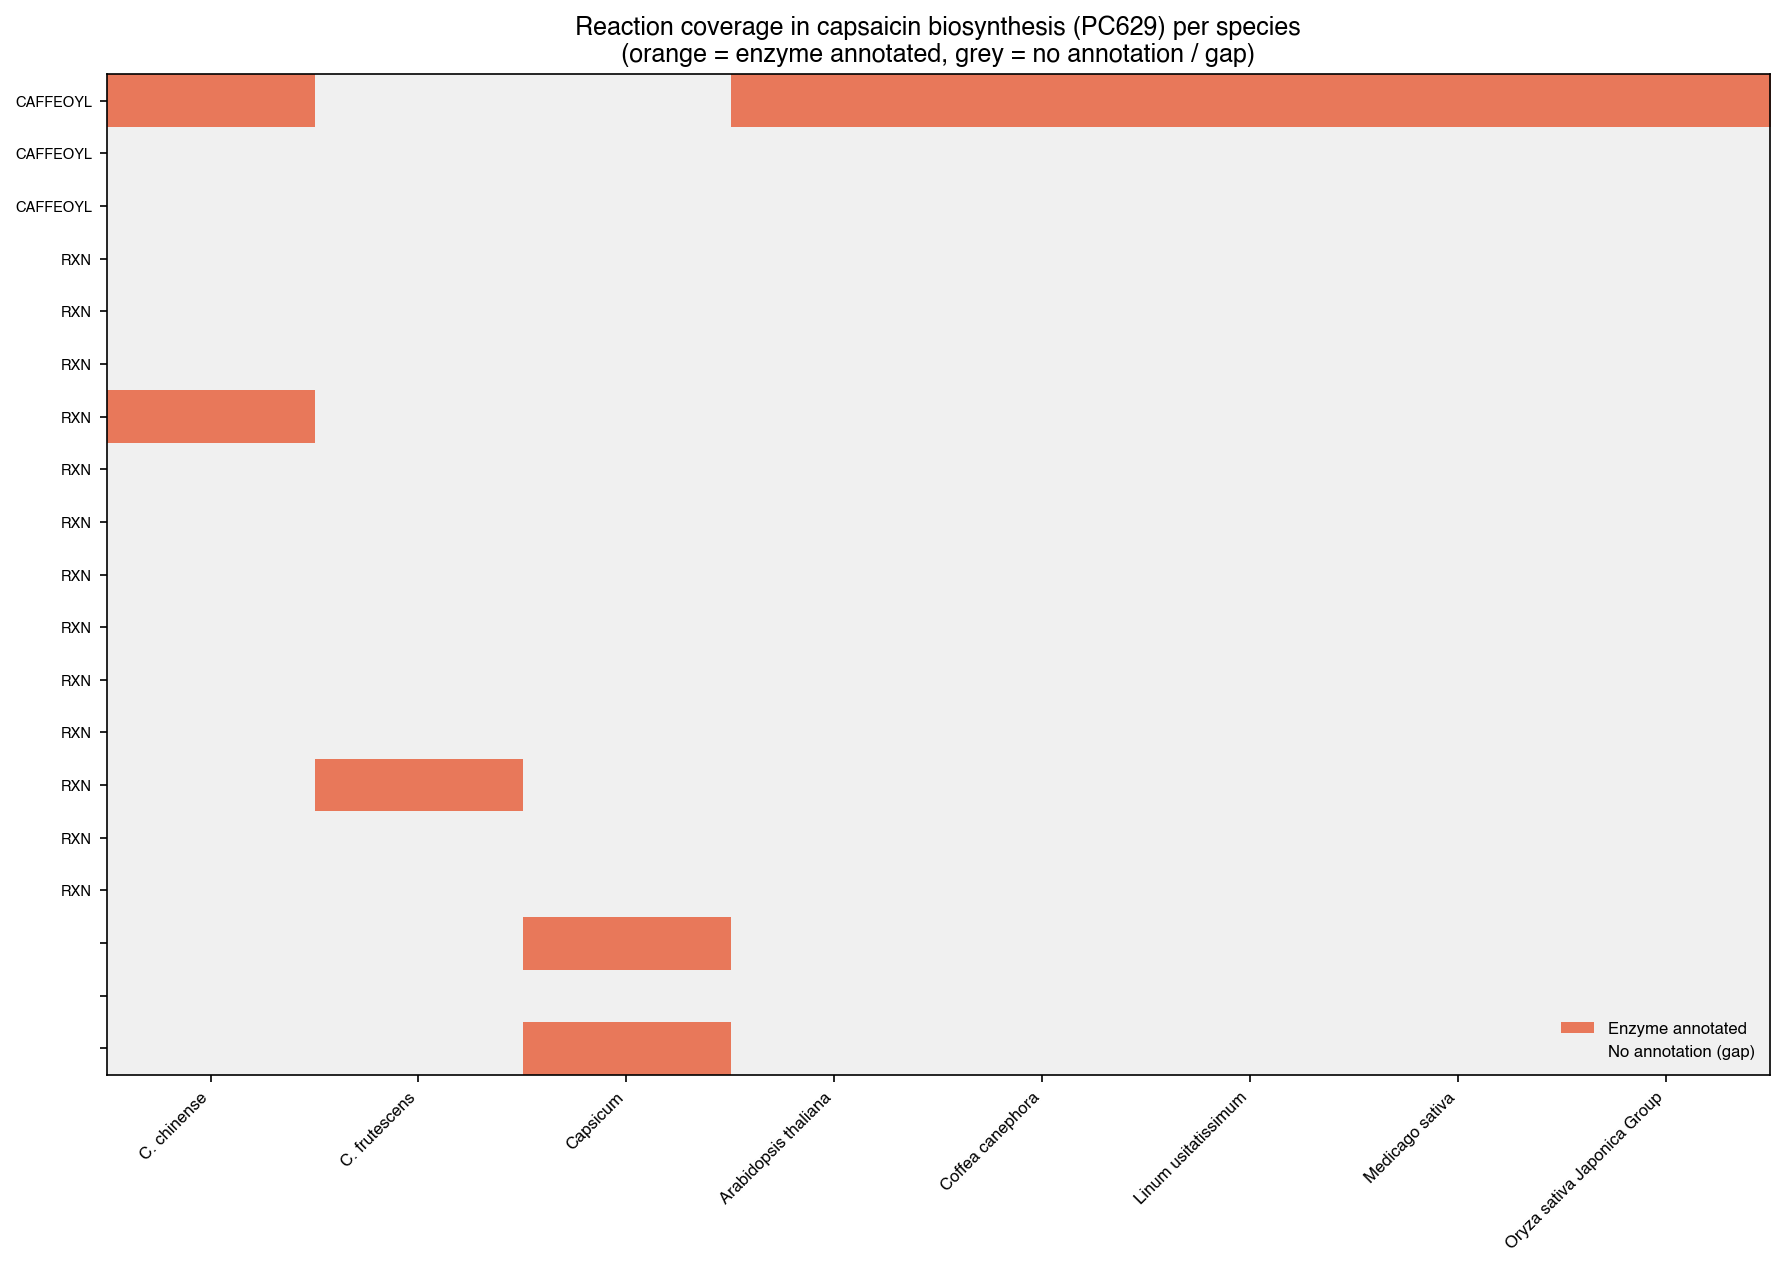

Matrix: 19 reactions x 8 species
Total annotated cells: 10 / 152


In [9]:
# All conversions in pathway
all_rxns = sparql(f"""
SELECT DISTINCT ?rxn (STR(?id) AS ?rxn_id)
WHERE {{
  GRAPH <{G_PW}> {{
    ?rxn a wp:Conversion ; dcterms:isPartOf <{PW629}> .
    OPTIONAL {{ ?rxn dc:identifier ?id }}
  }}
}}
""")
ensure_col(all_rxns, 'rxn_id', '')
# Short label: PlantCyc ID from identifier or IRI tail
all_rxns['label'] = all_rxns['rxn_id'].str.split('/').str[-1].where(
    all_rxns['rxn_id'] != '', all_rxns['rxn'].str.split('/').str[-1].str.split('_').str[0])

# Species→reaction coverage via wp:Catalysis
covered = sparql(f"""
SELECT DISTINCT ?species_name ?rxn
WHERE {{
  GRAPH <{G_TAX}> {{ ?enzyme wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{
    ?enzyme dcterms:isPartOf <{PW629}> .
    ?cat a wp:Catalysis ; wp:source ?enzyme ; wp:target ?rxn .
    ?rxn a wp:Conversion ; dcterms:isPartOf <{PW629}> .
  }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?species_name }}
}}
""")

# Build coverage matrix
species_order = ['Capsicum annuum','Capsicum chinense','Capsicum frutescens','Capsicum',
                 'Arabidopsis thaliana']
species_in_data = [s for s in species_order if s in covered['species_name'].values]
all_sp = sorted(set(covered['species_name']) - set(species_order))
species_cols = species_in_data + all_sp

rxn_label_map = dict(zip(all_rxns['rxn'], all_rxns['label']))
row_labels = [rxn_label_map.get(r, r.split('/')[-1]) for r in all_rxns['rxn']]
matrix = pd.DataFrame(0, index=all_rxns['rxn'].tolist(), columns=species_cols)
for _, row in covered.iterrows():
    if row['rxn'] in matrix.index and row['species_name'] in matrix.columns:
        matrix.loc[row['rxn'], row['species_name']] = 1
matrix.index = row_labels

# Visualise
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(max(8, len(species_cols)*1.5), max(5, len(matrix)*0.45)))
cmap = mpl.colors.ListedColormap(['#f0f0f0','#e8785a'])
ax.imshow(matrix.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(species_cols)))
ax.set_xticklabels([s.replace('Capsicum ','C. ') for s in species_cols],
                   rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(matrix)))
ax.set_yticklabels(matrix.index, fontsize=7)
ax.set_title('Reaction coverage in capsaicin biosynthesis (PC629) per species\n'
             '(orange = enzyme annotated, grey = no annotation / gap)')
ax.legend(handles=[Patch(facecolor='#e8785a', label='Enzyme annotated'),
                   Patch(facecolor='#f0f0f0', label='No annotation (gap)')],
          loc='lower right', frameon=False, fontsize=8)
plt.tight_layout()
import pathlib; pathlib.Path('figures/output/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('figures/output/figures/capsaicin_species_coverage_matrix.pdf', bbox_inches='tight')
plt.savefig('figures/output/figures/capsaicin_species_coverage_matrix.svg', bbox_inches='tight')
plt.show()
print(f"Matrix: {len(matrix)} reactions x {len(species_cols)} species")
print(f"Total annotated cells: {int(matrix.sum().sum())} / {len(matrix)*len(species_cols)}")


> **Key result:** The coverage matrix reveals which enzymatic steps are annotated per species
> and — crucially — which steps are **gaps** (grey cells).
>
> *Capsicum annuum* has **no annotated enzymes** in this pathway despite being the most
> well-annotated *Capsicum* species in the database overall. This represents a genuine
> annotation gap: the capsaicin pathway is present in *C. annuum* biochemically, but no
> enzyme nodes have been curated in this species's PlantCyc database for this pathway.
>
> Steps annotated in *C. chinense*, *C. frutescens*, or the genus *Capsicum* provide
> **cross-species evidence** that can be transferred to *C. annuum* via shared reactions.


---
## Step 8 — Shared metabolites: the chemical backbone common to all species

Metabolites in PlantMetWiki carry no direct species annotation — they are shared across
the pathway. This makes them ideal anchors for cross-species inference: a metabolite
present in the pathway is implicitly relevant to **all species** with any annotation in it.


In [10]:
metabolites_df = sparql(f"""
SELECT ?metabolite (STR(?mid) AS ?identifier) (STR(?lbl) AS ?label)
WHERE {{
  GRAPH <{G_PW}> {{
    ?metabolite a wp:Metabolite ; dcterms:isPartOf <{PW629}> .
    OPTIONAL {{ ?metabolite dc:identifier ?mid }}
    OPTIONAL {{ ?metabolite rdfs:label    ?lbl }}
  }}
}}
ORDER BY ?lbl
""")
ensure_col(metabolites_df, 'label', '')
ensure_col(metabolites_df, 'identifier', '')

print(f'{len(metabolites_df)} metabolites in PC629 (shared across all species):')
print()
for _, row in metabolites_df.iterrows():
    lbl = row['label'] or row['identifier'].split('/')[-1]
    mid = row['identifier'].replace('https://identifiers.org/inchikey/','InChIKey:')
    print(f'  {lbl:45s}  {mid}')


27 metabolites in PC629 (shared across all species):

  (E)-8-methylnon-6-enoate                       InChIKey:OCALSPDXYQHUHA-FNORWQNLSA-M
  (E)-8-methylnon-6-enoyl-CoA                    InChIKey:JGNCYWQFXLYWMO-RSERDAIDSA-J
  (E)-caffeoyl-CoA                               InChIKey:QHRGJMIMHCLHRG-ZSELIEHESA-J
  3-hydroxy-3-(4-hydroxy-3-methoxyphenyl)propanoyl-CoA  InChIKey:SDNPOBCYTJKZSD-XWQDBIPASA-J
  ADP                                            InChIKey:XTWYTFMLZFPYCI-KQYNXXCUSA-K
  ATP                                            InChIKey:ZKHQWZAMYRWXGA-KQYNXXCUSA-J
  Ca²⁺                                           InChIKey:BHPQYMZQTOCNFJ-UHFFFAOYSA-N
  Co²⁺                                           InChIKey:XLJKHNWPARRRJB-UHFFFAOYSA-N
  Cu²⁺                                           InChIKey:JPVYNHNXODAKFH-UHFFFAOYSA-N
  H⁺                                             InChIKey:GPRLSGONYQIRFK-UHFFFAOYSA-N
  H₂O                                            InChIKey:XLYOFNOQVPJJNP-UHFFFA

> **Observation:** 27 metabolites are present in PC629, linked to InChIKey identifiers
> (enabling cross-database lookups via BridgeDB). Key pathway intermediates include
> **vanillylamine**, **feruloyl-CoA**, **capsaicin** itself, and cofactors (CoA, NADPH, SAM).
>
> Because these metabolites carry no `wp:organism` tag, they are attributed to **all 9 species**
> in the pathway via the indirect co-occurrence strategy (see Figure 6b in the figures notebook).


---
## Step 9 — Cross-species inference: using related species to fill annotation gaps

We now ask: for each reaction gap in *C. annuum*, is there evidence from a related species
in the same pathway? We identify reactions with annotations in at least one other
*Capsicum* species (or phylogenetically related species) but not in *C. annuum*.


In [11]:
CAP_ANNUUM = 'http://purl.obolibrary.org/obo/NCBITaxon_4072'

covered_by_others = sparql(f"""
SELECT DISTINCT ?rxn ?evidence_species
WHERE {{
  GRAPH <{G_PW}> {{ ?rxn a wp:Conversion ; dcterms:isPartOf <{PW629}> }}
  GRAPH <{G_TAX}> {{ ?enzyme wp:organism ?evidence_taxon . FILTER(?evidence_taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{
    ?enzyme dcterms:isPartOf <{PW629}> .
    ?cat a wp:Catalysis ; wp:source ?enzyme ; wp:target ?rxn .
  }}
  GRAPH <{G_NCBI}> {{ ?evidence_taxon rdfs:label ?evidence_species }}
  FILTER NOT EXISTS {{
    GRAPH <{G_TAX}> {{ ?ca_enzyme wp:organism <{CAP_ANNUUM}> }}
    GRAPH <{G_PW}>  {{
      ?ca_enzyme dcterms:isPartOf <{PW629}> .
      ?ca_cat a wp:Catalysis ; wp:source ?ca_enzyme ; wp:target ?rxn .
    }}
  }}
}}
ORDER BY ?rxn ?evidence_species
""")

if not covered_by_others.empty:
    covered_by_others['rxn_short'] = covered_by_others['rxn'].str.split('/').str[-1].str.split('_').str[0]
    print(f'{len(covered_by_others)} (reaction, species) inference pairs:')
    print(covered_by_others[['rxn_short','evidence_species']].to_string(index=False))
else:
    print('All reactions are gaps for C. annuum (no enzyme annotations in PC629).')
    print()
    print('Evidence from other Capsicum species for these gaps:')
    for _, row in rxn_per_sp.iterrows():
        print(f"  {row.get('rxn_short', row['rxn'].split('/')[-1]):25s}  via {row['species_name']}")


10 (reaction, species) inference pairs:
rxn_short            evidence_species
 CAFFEOYL        Arabidopsis thaliana
 CAFFEOYL           Capsicum chinense
 CAFFEOYL            Coffea canephora
 CAFFEOYL         Linum usitatissimum
 CAFFEOYL             Medicago sativa
 CAFFEOYL Oryza sativa Japonica Group
      RXN           Capsicum chinense
      RXN         Capsicum frutescens
                             Capsicum
                             Capsicum


> **Cross-species inference result:**
> Since *Capsicum annuum* has no annotations in PC629, **all 19 conversion steps** are
> potential inference targets. The reactions already annotated in *C. chinense*, *C. frutescens*,
> and the genus *Capsicum* provide the strongest transfer candidates, as they represent
> the same biochemical pathway in closely related taxa.
>
> The 6 *Arabidopsis thaliana* annotations provide additional phylogenetic evidence for
> enzyme–reaction assignments that may be conserved across Solanaceae.
>
> This analysis demonstrates that PlantMetWiki enables **structured gap identification**:
> by querying the knowledge graph, researchers can prioritise which enzyme–reaction pairs
> to target for experimental validation or computational gene-function prediction in *C. annuum*.


---
## Summary

| Question | Answer |
|----------|--------|
| *Capsicum* species in PlantMetWiki | 4 (genus + 3 species) |
| *C. annuum* total pathways | 34 |
| **Is capsaicin biosynthesis (PC629) annotated for *C. annuum*?** | **No — zero directly annotated nodes** |
| Species annotated in PC629 | 9 (incl. *C. chinense*, *C. frutescens*, *Arabidopsis*) |
| Total reactions in PC629 | 19 `wp:Conversion` |
| Reactions with any *Capsicum* enzyme evidence | see matrix above |
| Metabolites in PC629 (shared) | 27 `wp:Metabolite` with InChIKey IDs |

**Take-home:** PlantMetWiki reveals that the capsaicin biosynthesis pathway exists in the
knowledge graph with multi-species evidence, but the primary commercial pepper species
(*C. annuum*) lacks direct enzyme annotations in this pathway. Cross-species inference
using shared reactions and metabolites — enabled by the PlantMetWiki multi-graph RDF
architecture — identifies concrete enzyme–reaction targets for annotation transfer.

### SPARQL endpoint (public)
```
https://sparql-plantmetwiki.bioinformatics.nl/sparql
```
All queries in this notebook can be run directly against the public endpoint by replacing
`http://localhost:8890/sparql` with the URL above.


---
## Appendix — Semantic model: the three-graph RDF architecture

This section illustrates how a pathway node and one of its DataNodes are encoded across
the three named graphs of PlantMetWiki, using PC629 (capsaicin biosynthesis) and the
*C. chinense* capsaicin synthase (MONOMER-13528, UniProt O81646) as a concrete example.

| Named graph | Purpose |
|---|---|
| `graph/pathways` (core) | WikiPathways RDF from `gpml2rdf`: types, labels, identifiers, literature references, coarse `wp:organism` |
| `graph/gpml-taxonomy-extra` | Enrichment layer: per-DataNode and per-pathway `wp:organism` with OBO Foundry NCBITaxon IRIs |
| `graph/gpml-properties-extra` | PlantCyc property layer: GPML `<Property>` key–value pairs as `pmw:gpmlProperty` blank nodes |

In [12]:
# Verify the key triples that appear in the semantic model diagram
G_PROP      = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/gpml-properties-extra'
MONOMER_IRI = 'https://identifiers.org/uniprot/O81646'   # MONOMER-13528 (wp:Protein)
PMW         = 'http://rdf-plantmetwiki.bioinformatics.nl/vocab/'

def sparql_pmw(query, timeout=60):
    """sparql() variant that also injects the pmw: prefix."""
    return sparql(f'PREFIX pmw: <{PMW}>\n' + query, timeout=timeout)

# ── 1. Core triples for PC629 ─────────────────────────────────────────────────
core_pc629 = sparql(f"""
SELECT ?pred ?obj
WHERE {{
  GRAPH <{G_PW}> {{
    <{PW629}> ?pred ?obj .
    FILTER(?pred IN (dc:title, dc:identifier, wp:organism))
  }}
}}
""")
core_pc629['pred_short'] = core_pc629['pred'].str.split('#').str[-1].str.split('/').str[-1]
core_pc629['obj_short']  = core_pc629['obj'].str.split('/').str[-1].str[:60]
print("graph/pathways — core triples for PC629:")
print(core_pc629[['pred_short', 'obj_short']].to_string(index=False))

# ── 2. Taxonomy-extra for PC629 and MONOMER-13528 ─────────────────────────────
print()
tax_nodes = sparql(f"""
SELECT ?subject ?taxon ?label
WHERE {{
  GRAPH <{G_TAX}> {{
    ?subject wp:organism ?taxon .
    FILTER(?subject IN (<{PW629}>, <{MONOMER_IRI}>))
  }}
  OPTIONAL {{ GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?label }} }}
}}
""")
tax_nodes['subject_short'] = tax_nodes['subject'].str.split('/').str[-1].str[:40]
tax_nodes['taxon_id']      = tax_nodes['taxon'].str.extract(r'NCBITaxon_(\d+)').apply(
    lambda x: f'NCBITaxon:{x[0]}' if pd.notna(x[0]) else tax_nodes['taxon'], axis=1)
print("graph/gpml-taxonomy-extra — wp:organism triples:")
print(tax_nodes[['subject_short', 'taxon', 'label']].to_string(index=False))

# ── 3. Properties-extra for PC629 ─────────────────────────────────────────────
print()
props = sparql_pmw(f"""
SELECT ?key ?value
WHERE {{
  GRAPH <{G_PROP}> {{
    <{PW629}> pmw:gpmlProperty ?bnode .
    ?bnode pmw:key ?key ; pmw:value ?value .
  }}
}}
ORDER BY ?key
LIMIT 4
""")
print("graph/gpml-properties-extra — pmw:gpmlProperty key-value pairs for PC629:")
print(props.to_string(index=False) if not props.empty else "  (none found)")

graph/pathways — core triples for PC629:
pred_short              obj_short
  organism       NCBITaxon_131567
identifier                  PC629
     title capsaicin biosynthesis

graph/gpml-taxonomy-extra — wp:organism triples:
               subject_short                                          taxon             label
PC629_r17.0.0_20260520160610 http://purl.obolibrary.org/obo/NCBITaxon_33090     Viridiplantae
                      O81646 http://purl.obolibrary.org/obo/NCBITaxon_80379 Capsicum chinense

graph/gpml-properties-extra — pmw:gpmlProperty key-value pairs for PC629:
                 key                                                             value
InstanceNameTemplate                                                             PWY-*
            Organism Capsicum, Capsicum annuum, Capsicum chinense, Capsicum frutescens
    PredecessorCount                                                                 6
PrimaryCompoundCount                                                

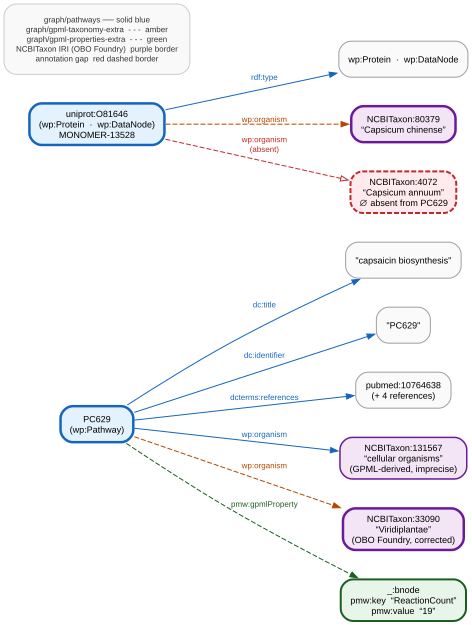

Saved: figures/output/figures/capsaicin_semantic_model.svg  +  .pdf


In [13]:
import graphviz
import pathlib
from IPython.display import SVG, display

# ── Color palette ──────────────────────────────────────────────────────────────
C_CORE    = '#1565c0'   # graph/pathways — solid blue
C_TAX     = '#b34700'   # graph/gpml-taxonomy-extra — dashed amber
C_PROP    = '#1b5e20'   # graph/gpml-properties-extra — dashed green
C_NCBI_BG = '#f3e5f5'   # NCBITaxon node background (light purple)
C_NCBI_BD = '#6a1b9a'   # NCBITaxon node border (dark purple)
C_GAP     = '#c62828'   # Annotation gap node / edge
C_SUBJ    = '#e3f2fd'   # Subject node background (light blue)
C_LIT     = '#fafafa'   # Literal / class value node background
C_LIT_BD  = '#9e9e9e'   # Literal node border

dot = graphviz.Digraph(engine='dot', format='svg')
dot.attr(rankdir='LR', nodesep='0.4', ranksep='1.1',
         fontname='Arial', fontsize='10', bgcolor='white')
dot.attr('node', fontname='Arial', fontsize='9', margin='0.12,0.07',
         shape='box', style='rounded,filled')
dot.attr('edge', fontname='Arial', fontsize='8', arrowsize='0.75')

# ── Subject nodes (left column) ────────────────────────────────────────────────
dot.node('pc629',
         'PC629\n(wp:Pathway)',
         fillcolor=C_SUBJ, color=C_CORE, penwidth='2.5')
dot.node('monomer',
         'uniprot:O81646\n(wp:Protein  ·  wp:DataNode)\nMONOMER-13528',
         fillcolor=C_SUBJ, color=C_CORE, penwidth='2.5')

with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('pc629')
    s.node('monomer')

# ── Objects from graph/pathways (core, solid blue edges) ──────────────────────
dot.node('title_lit',   '"capsaicin biosynthesis"',
         fillcolor=C_LIT, color=C_LIT_BD)
dot.node('id_lit',      '"PC629"',
         fillcolor=C_LIT, color=C_LIT_BD)
dot.node('pubmed_lit',  'pubmed:10764638\n(+ 4 references)',
         fillcolor=C_LIT, color=C_LIT_BD)
dot.node('ncbi_131567', 'NCBITaxon:131567\n“cellular organisms”\n(GPML-derived, imprecise)',
         fillcolor=C_NCBI_BG, color=C_NCBI_BD, penwidth='1.5')
dot.node('rdf_types',   'wp:Protein  ·  wp:DataNode',
         fillcolor=C_LIT, color=C_LIT_BD)

core = dict(color=C_CORE, fontcolor=C_CORE)
dot.edge('pc629',   'title_lit',    label='dc:title',           **core)
dot.edge('pc629',   'id_lit',       label='dc:identifier',      **core)
dot.edge('pc629',   'pubmed_lit',   label='dcterms:references', **core)
dot.edge('pc629',   'ncbi_131567',  label='wp:organism',        **core)
dot.edge('monomer', 'rdf_types',    label='rdf:type',           **core)

# ── Objects from graph/gpml-taxonomy-extra (dashed amber edges) ───────────────
dot.node('ncbi_33090',
         'NCBITaxon:33090\n“Viridiplantae”\n(OBO Foundry, corrected)',
         fillcolor=C_NCBI_BG, color=C_NCBI_BD, penwidth='2.5')
dot.node('ncbi_80379',
         'NCBITaxon:80379\n“Capsicum chinense”',
         fillcolor=C_NCBI_BG, color=C_NCBI_BD, penwidth='2.5')

tax = dict(color=C_TAX, fontcolor=C_TAX, style='dashed')
dot.edge('pc629',   'ncbi_33090', label='wp:organism', **tax)
dot.edge('monomer', 'ncbi_80379', label='wp:organism', **tax)

# ── Annotation gap: C. annuum absent from PC629 ────────────────────────────────
dot.node('ncbi_4072',
         'NCBITaxon:4072\n“Capsicum annuum”\n∅ absent from PC629',
         fillcolor='#ffebee', color=C_GAP, penwidth='2',
         style='rounded,dashed,filled')
dot.edge('monomer', 'ncbi_4072',
         label='wp:organism\n(absent)',
         color=C_GAP, fontcolor=C_GAP, style='dashed', arrowhead='empty')

# Keep both species-level taxa at the same rank
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('ncbi_80379')
    s.node('ncbi_4072')

# ── Objects from graph/gpml-properties-extra (dashed green edges) ─────────────
dot.node('prop1',
         '_:bnode\npmw:key  “ReactionCount”\npmw:value  “19”',
         fillcolor='#e8f5e9', color=C_PROP, penwidth='2')

prop = dict(color=C_PROP, fontcolor=C_PROP, style='dashed')
dot.edge('pc629', 'prop1', label='pmw:gpmlProperty', **prop)

# ── Legend ─────────────────────────────────────────────────────────────────────
legend = (
    'graph/pathways ── solid blue\n'
    'graph/gpml-taxonomy-extra  - - -  amber\n'
    'graph/gpml-properties-extra  - - -  green\n'
    'NCBITaxon IRI (OBO Foundry)  purple border\n'
    'annotation gap  red dashed border'
)
dot.node('legend', legend,
         shape='box', style='rounded,filled', fillcolor='#f9f9f9',
         color='#cccccc', fontname='Arial', fontsize='8', fontcolor='#333333',
         margin='0.15')

# ── Save & display ─────────────────────────────────────────────────────────────
out_dir = pathlib.Path('figures/output/figures')
out_dir.mkdir(parents=True, exist_ok=True)

dot.format = 'svg'
dot.render(str(out_dir / 'capsaicin_semantic_model'), cleanup=True)
dot.format = 'pdf'
dot.render(str(out_dir / 'capsaicin_semantic_model'), cleanup=True)

display(SVG(str(out_dir / 'capsaicin_semantic_model.svg')))
print(f"Saved: {out_dir}/capsaicin_semantic_model.svg  +  .pdf")

**Figure: Semantic model of a pathway node and a DataNode in the PlantMetWiki RDF architecture.**  
PC629 (capsaicin biosynthesis, `wp:Pathway`) and DataNode MONOMER-13528 (*Capsicum chinense* capsaicin synthase, UniProt O81646, `wp:Protein`) shown across three named graphs.
Solid blue edges originate from `graph/pathways` (core WikiPathways RDF, generated by `gpml2rdf`); dashed amber edges from `graph/gpml-taxonomy-extra` (species enrichment layer); dashed green edges from `graph/gpml-properties-extra` (PlantCyc property layer).
The core `wp:organism` on PC629 (NCBITaxon:131567, "cellular organisms") is the coarse GPML-derived value; the taxonomy-extra layer adds the corrected OBO Foundry IRI (NCBITaxon:33090, Viridiplantae).
The red dashed box (NCBITaxon:4072, *C. annuum*) marks the annotation gap from Step 4: despite being the most pathway-rich *Capsicum* species, *C. annuum* has no directly annotated enzyme in PC629.
MONOMER-13528 is connected to PC629 via `dcterms:isPartOf` in `graph/pathways` (omitted from the diagram for clarity).

---
## Appendix 2 — Complete DataNode RDF graph for PC629

This figure shows **all DataNodes** in the capsaicin biosynthesis pathway (PC629) and
their species annotations, drawing from two named graphs:

| Edge type | Predicate | Named graph |
|---|---|---|
| Solid grey ─── | `dcterms:isPartOf` (PC629 → species cluster) | `graph/pathways` |
| Node type | `rdf:type` (GeneProduct / Protein / Metabolite) | `graph/pathways` |
| Species cluster | `wp:organism` | `graph/gpml-taxonomy-extra` |

GeneProduct: 11  |  Protein: 13  |  Metabolite: 27
Annotated species (DataNode level): 9


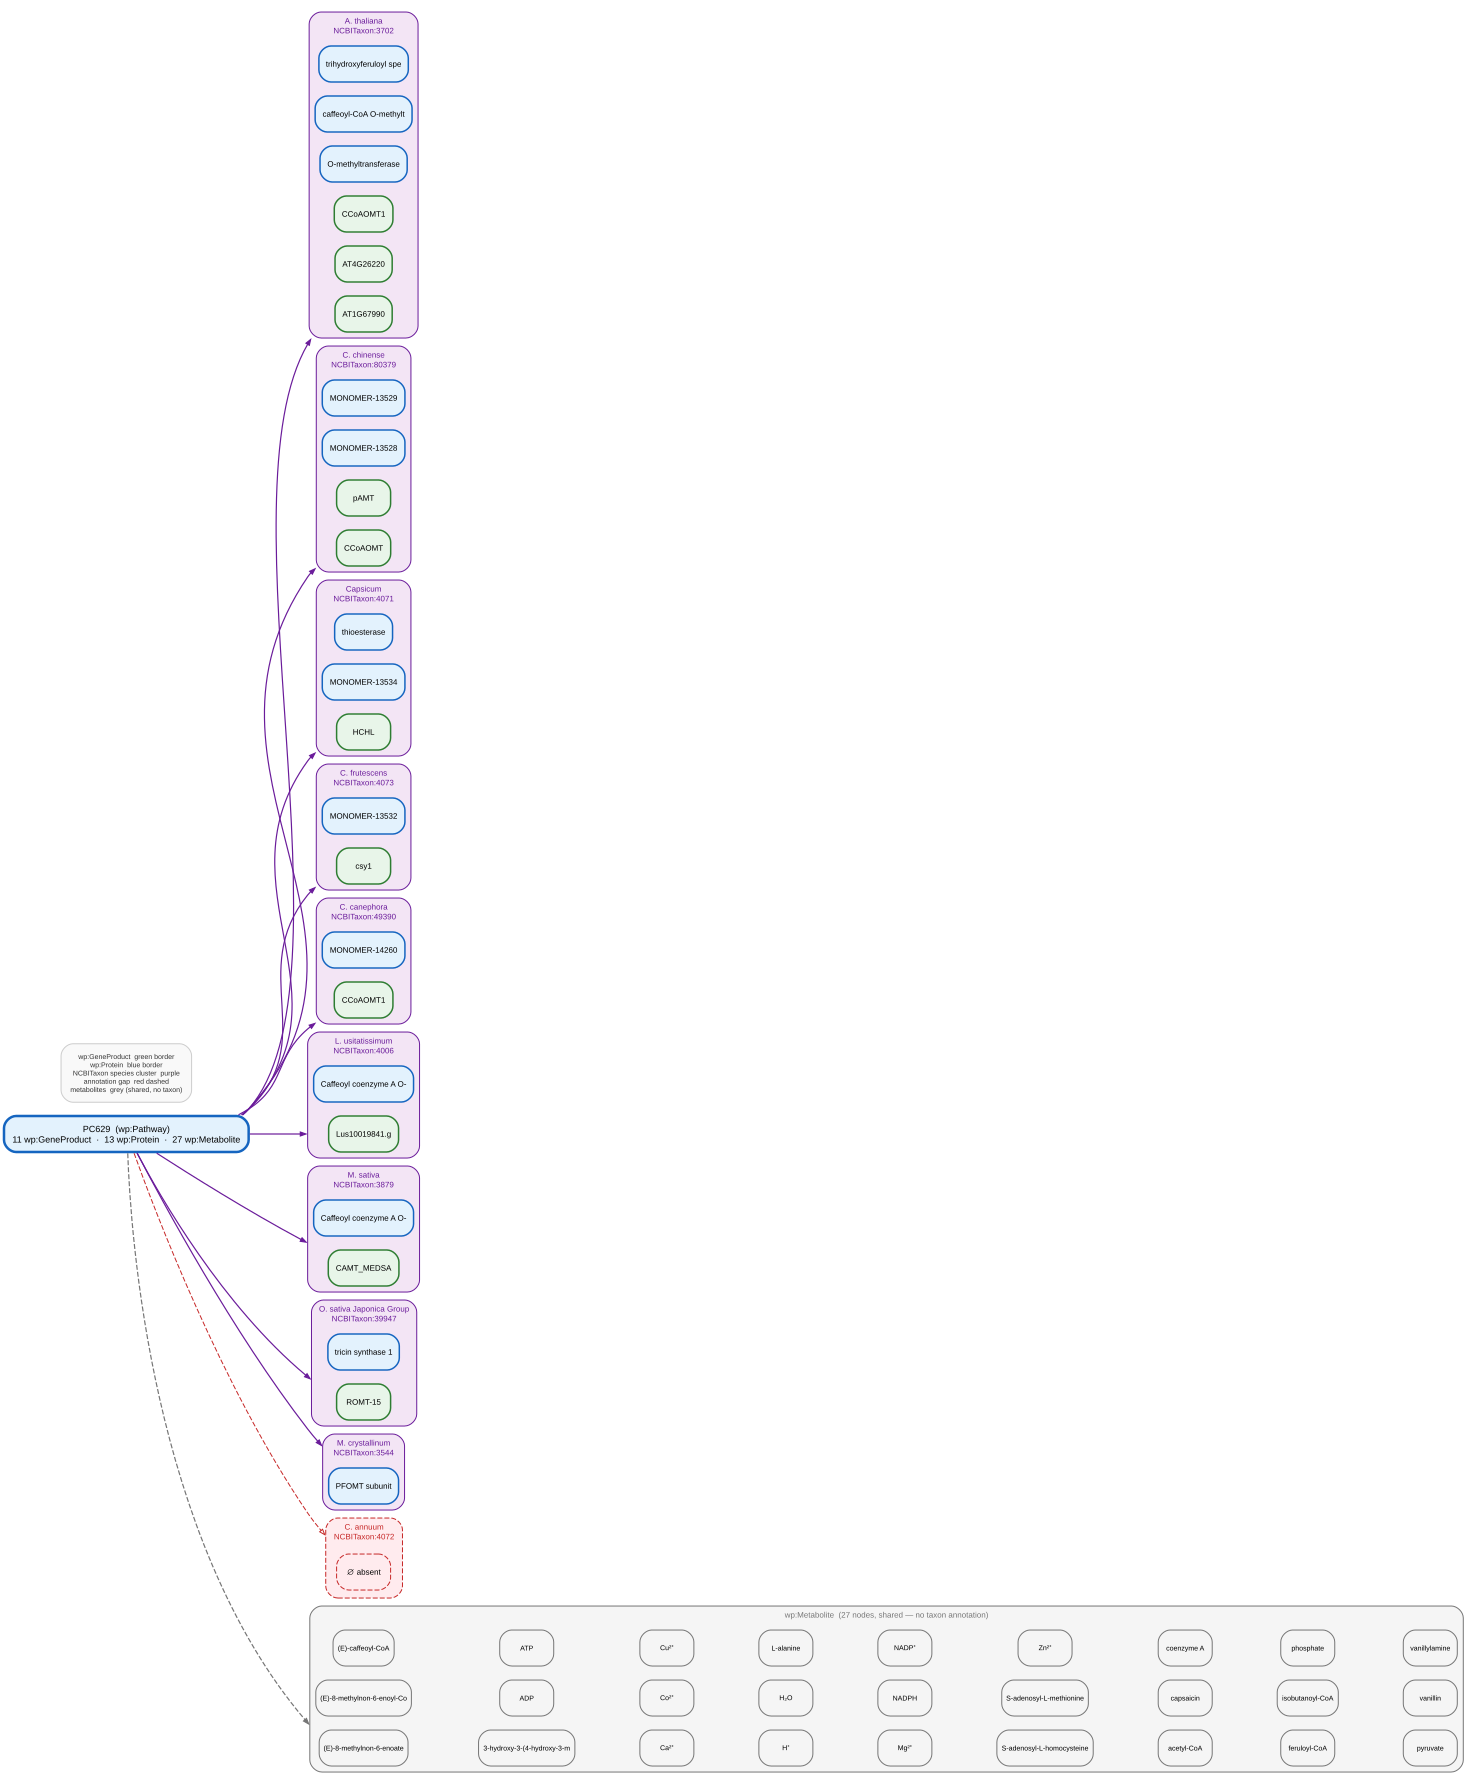

Saved: figures/output/figures/capsaicin_all_nodes.svg  +  .pdf


In [14]:
import graphviz, pathlib, hashlib
from IPython.display import SVG, display

# ── Color palette ──────────────────────────────────────────────────────────────
C_CORE    = '#1565c0'
C_GENE    = '#2e7d32'
C_GENE_BG = '#e8f5e9'
C_PROT_BG = '#e3f2fd'
C_NCBI_BG = '#f3e5f5'
C_NCBI_BD = '#6a1b9a'
C_GAP     = '#c62828'
C_MET_BD  = '#757575'
C_MET_BG  = '#f5f5f5'

def gv_id(iri):
    return 'n' + hashlib.md5(iri.encode()).hexdigest()[:10]

# ── Query 1: all GeneProducts and Proteins in PC629 ───────────────────────────
nodes_all = sparql(f"""
SELECT DISTINCT ?node ?type ?label ?identifier
WHERE {{
  GRAPH <{G_PW}> {{
    ?node dcterms:isPartOf <{PW629}> ; a ?type .
    FILTER(?type IN (wp:GeneProduct, wp:Protein))
    OPTIONAL {{ ?node rdfs:label    ?label      }}
    OPTIONAL {{ ?node dc:identifier ?identifier }}
  }}
}}
ORDER BY ?type ?label
""")
nodes_all['type_short']  = nodes_all['type'].str.replace(WP, 'wp:', regex=False)
nodes_all['label_short'] = nodes_all['label'].fillna(
    nodes_all['identifier'].str.split('/').str[-1])

# ── Query 2: all Metabolites in PC629 ─────────────────────────────────────────
mets_all = sparql(f"""
SELECT DISTINCT ?node ?label ?identifier
WHERE {{
  GRAPH <{G_PW}> {{
    ?node dcterms:isPartOf <{PW629}> ; a wp:Metabolite .
    OPTIONAL {{ ?node rdfs:label    ?label      }}
    OPTIONAL {{ ?node dc:identifier ?identifier }}
  }}
}}
ORDER BY ?label
""")
mets_all['label_short'] = mets_all['label'].fillna(
    mets_all['identifier'].str.split('/').str[-1])

# ── Query 3: taxonomy annotations for all DataNodes in PC629 ──────────────────
tax_pw = sparql(f"""
SELECT DISTINCT ?node ?taxon ?taxon_label
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node dcterms:isPartOf <{PW629}> }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?taxon_label }}
}}
""")

# Merge genes/proteins with their taxonomy annotations
data = nodes_all.merge(tax_pw, on='node', how='left')
data['taxon_label'] = data['taxon_label'].fillna('unannotated')
data['taxon']       = data['taxon'].fillna('')

n_gene = (nodes_all['type_short'] == 'wp:GeneProduct').sum()
n_prot = (nodes_all['type_short'] == 'wp:Protein').sum()
sp_order = (data[data['taxon_label'] != 'unannotated']
            .groupby('taxon_label').size()
            .sort_values(ascending=False).index)
print(f"GeneProduct: {n_gene}  |  Protein: {n_prot}  |  Metabolite: {len(mets_all)}")
print(f"Annotated species (DataNode level): {len(sp_order)}")

# ── Build Graphviz diagram ─────────────────────────────────────────────────────
# rankdir=LR: PC629 on the left, species clusters stack vertically on the right.
dot = graphviz.Digraph(engine='dot', format='svg')
dot.attr(rankdir='LR', nodesep='0.20', ranksep='0.9', compound='true',
         fontname='Arial', fontsize='10', bgcolor='white')
dot.attr('node', fontname='Arial', fontsize='8', margin='0.10,0.05',
         shape='box', style='rounded,filled')
dot.attr('edge', fontname='Arial', fontsize='7', arrowsize='0.55', color='#888888')

# PC629 on the left
dot.node('pw_pc629',
         f'PC629  (wp:Pathway)\n'
         f'{n_gene} wp:GeneProduct  ·  {n_prot} wp:Protein  ·  {len(mets_all)} wp:Metabolite',
         fillcolor='#e3f2fd', color=C_CORE, penwidth='2.5', fontsize='9')

# One species cluster per annotated species (sorted by node count desc)
for sp_name in sp_order:
    grp   = data[data['taxon_label'] == sp_name]
    taxon = grp['taxon'].iloc[0]
    tnum  = taxon.split('_')[-1]
    cn    = f'cluster_s{tnum}'
    parts = sp_name.split()
    sp_abbr = f'{parts[0][0]}. {" ".join(parts[1:])}' if len(parts) > 1 else sp_name

    with dot.subgraph(name=cn) as c:
        c.attr(label=f'{sp_abbr}\nNCBITaxon:{tnum}', labelloc='t',
               style='rounded', color=C_NCBI_BD, bgcolor=C_NCBI_BG,
               fontname='Arial', fontsize='8', fontcolor=C_NCBI_BD, margin='6')
        first = None
        for _, row in grp.iterrows():
            v   = gv_id(row['node'])
            lbl = str(row['label_short'])[:22]
            if first is None: first = v
            if row['type_short'] == 'wp:GeneProduct':
                c.node(v, lbl, fillcolor=C_GENE_BG, color=C_GENE, penwidth='1.5')
            else:
                c.node(v, lbl, fillcolor=C_PROT_BG, color=C_CORE, penwidth='1.5')

    dot.edge('pw_pc629', first, lhead=cn, color=C_NCBI_BD, penwidth='1.2')

# C. annuum annotation gap
with dot.subgraph(name='cluster_sgap') as c:
    c.attr(label='C. annuum\nNCBITaxon:4072', labelloc='t',
           style='rounded,dashed', color=C_GAP, bgcolor='#ffebee',
           fontname='Arial', fontsize='8', fontcolor=C_GAP, margin='8')
    c.node('node_gap', '∅ absent',
           fillcolor='#ffebee', color=C_GAP,
           style='rounded,dashed,filled', fontsize='8')
dot.edge('pw_pc629', 'node_gap', lhead='cluster_sgap',
         color=C_GAP, style='dashed', arrowhead='empty')

# Metabolites cluster — arranged in 3 columns using rank=same groups
with dot.subgraph(name='cluster_mets') as c:
    c.attr(label=f'wp:Metabolite  ({len(mets_all)} nodes, shared — no taxon annotation)',
           labelloc='t', style='rounded', color=C_MET_BD, bgcolor=C_MET_BG,
           fontname='Arial', fontsize='8', fontcolor=C_MET_BD, margin='6')
    c.attr('node', fontsize='7', margin='0.07,0.03')
    met_ids = []
    for _, row in mets_all.iterrows():
        v   = gv_id(row['node'])
        lbl = str(row['label_short'])[:26]
        met_ids.append(v)
        c.node(v, lbl, fillcolor=C_MET_BG, color=C_MET_BD)
    # Invisible vertical chains to form 3 columns
    n_cols = 3
    for col in range(n_cols):
        col_nodes = met_ids[col::n_cols]
        for i in range(len(col_nodes) - 1):
            c.edge(col_nodes[i], col_nodes[i + 1], style='invis', weight='10')
    # rank=same forces nodes in each row to align horizontally
    for row_start in range(0, len(met_ids), n_cols):
        row_nodes = met_ids[row_start:row_start + n_cols]
        with c.subgraph() as s:
            s.attr(rank='same')
            for v in row_nodes:
                s.node(v)

first_m = met_ids[0] if met_ids else None
if first_m:
    dot.edge('pw_pc629', first_m, lhead='cluster_mets',
             color=C_MET_BD, style='dashed', penwidth='1.2')

# Legend
dot.node('legend',
         'wp:GeneProduct  green border\n'
         'wp:Protein  blue border\n'
         'NCBITaxon species cluster  purple\n'
         'annotation gap  red dashed\n'
         'metabolites  grey (shared, no taxon)',
         shape='box', style='rounded,filled', fillcolor='#f9f9f9',
         color='#cccccc', fontname='Arial', fontsize='7',
         fontcolor='#333333', margin='0.12')

# ── Save & display ─────────────────────────────────────────────────────────────
out_dir = pathlib.Path('figures/output/figures')
out_dir.mkdir(parents=True, exist_ok=True)
dot.format = 'svg'
dot.render(str(out_dir / 'capsaicin_all_nodes'), cleanup=True)
dot.format = 'pdf'
dot.render(str(out_dir / 'capsaicin_all_nodes'), cleanup=True)
display(SVG(str(out_dir / 'capsaicin_all_nodes.svg')))
print(f"Saved: {out_dir}/capsaicin_all_nodes.svg  +  .pdf")


**Figure: All DataNodes in PC629 and their species annotations across the two RDF graphs.**  
Each species cluster (purple border) shows the annotated gene products (green border, `wp:GeneProduct`) and proteins (blue border, `wp:Protein`) for that species.
Species assignments come from `graph/gpml-taxonomy-extra` (`wp:organism`); node labels, types, and identifiers come from `graph/pathways` (core).
The red dashed cluster marks the *C. annuum* annotation gap: NCBITaxon:4072 is absent from PC629 despite being the most pathway-rich *Capsicum* species in PlantMetWiki.
The grey cluster shows all 27 `wp:Metabolite` nodes; metabolites carry no direct species annotation and are shared across all annotated species.

---
## Appendix 3 — Complete DataNode RDF graph for PC629 (v2, concentric network)

This is a second representation of the same data as Appendix 2, but **without any
clustering/grouping** — every resource (pathway, `rdfs:Class`, DataNode instance,
NCBITaxon species) is drawn as an individual node, and **every triple is drawn as an
individual edge**, labelled with its predicate. PC629 is placed at the centre and the
graph is laid out as **concentric rings** ("network node" / radial layout):

| Ring (centre → out) | Resources | Source named graph |
|---|---|---|
| 0 — centre | PC629 (`wp:Pathway`) | `graph/pathways` (core) |
| 1 | `rdfs:Class` nodes: `wp:Pathway`, `wp:GeneProduct`, `wp:Protein`, `wp:Metabolite` | `graph/pathways` (core) |
| 2 | All 51 DataNode instances (`wp:GeneProduct`, `wp:Protein`, `wp:Metabolite`) | `graph/pathways` (core) |
| 3 | 9 `NCBITaxon` species nodes | `graph/gpml-taxonomy-extra` |

| Edge type (predicate) | Direction (subject → object) | Source named graph |
|---|---|---|
| `dcterms:isPartOf` | DataNode instance → PC629 | `graph/pathways` |
| `rdf:type` | DataNode instance → its class; PC629 → `wp:Pathway` | `graph/pathways` |
| `wp:organism` | DataNode instance → NCBITaxon species | `graph/gpml-taxonomy-extra` |

Node colour encodes which named graph a resource originates from: **blue/green shades =
core `graph/pathways`**, **purple = `graph/gpml-taxonomy-extra`**. Node *shape* encodes
RDF type (circle = DataNode instance, diamond = `rdfs:Class`, triangle = `NCBITaxon`).
A representative edge of each predicate is labelled directly on the figure, and the full
legend ("agenda") lists all node and edge types with their colours.

This cell also exports the graph as **GraphML** and **Cytoscape.js JSON (`.cyjs`)** for
further exploration/editing in [Cytoscape Desktop](https://cytoscape.org/): use
*File → Import → Network from File…* and select `capsaicin_all_nodes_v2.graphml`, then
*Layout → Concentric Layout* using the `level` node attribute (0 = PC629 … 3 = NCBITaxon)
to reproduce the concentric arrangement.

wp:GeneProduct/wp:Protein: 24  wp:Metabolite: 27  wp:organism edges: 24  NCBITaxon nodes: 9
Total nodes: 65  Total edges (triples): 127


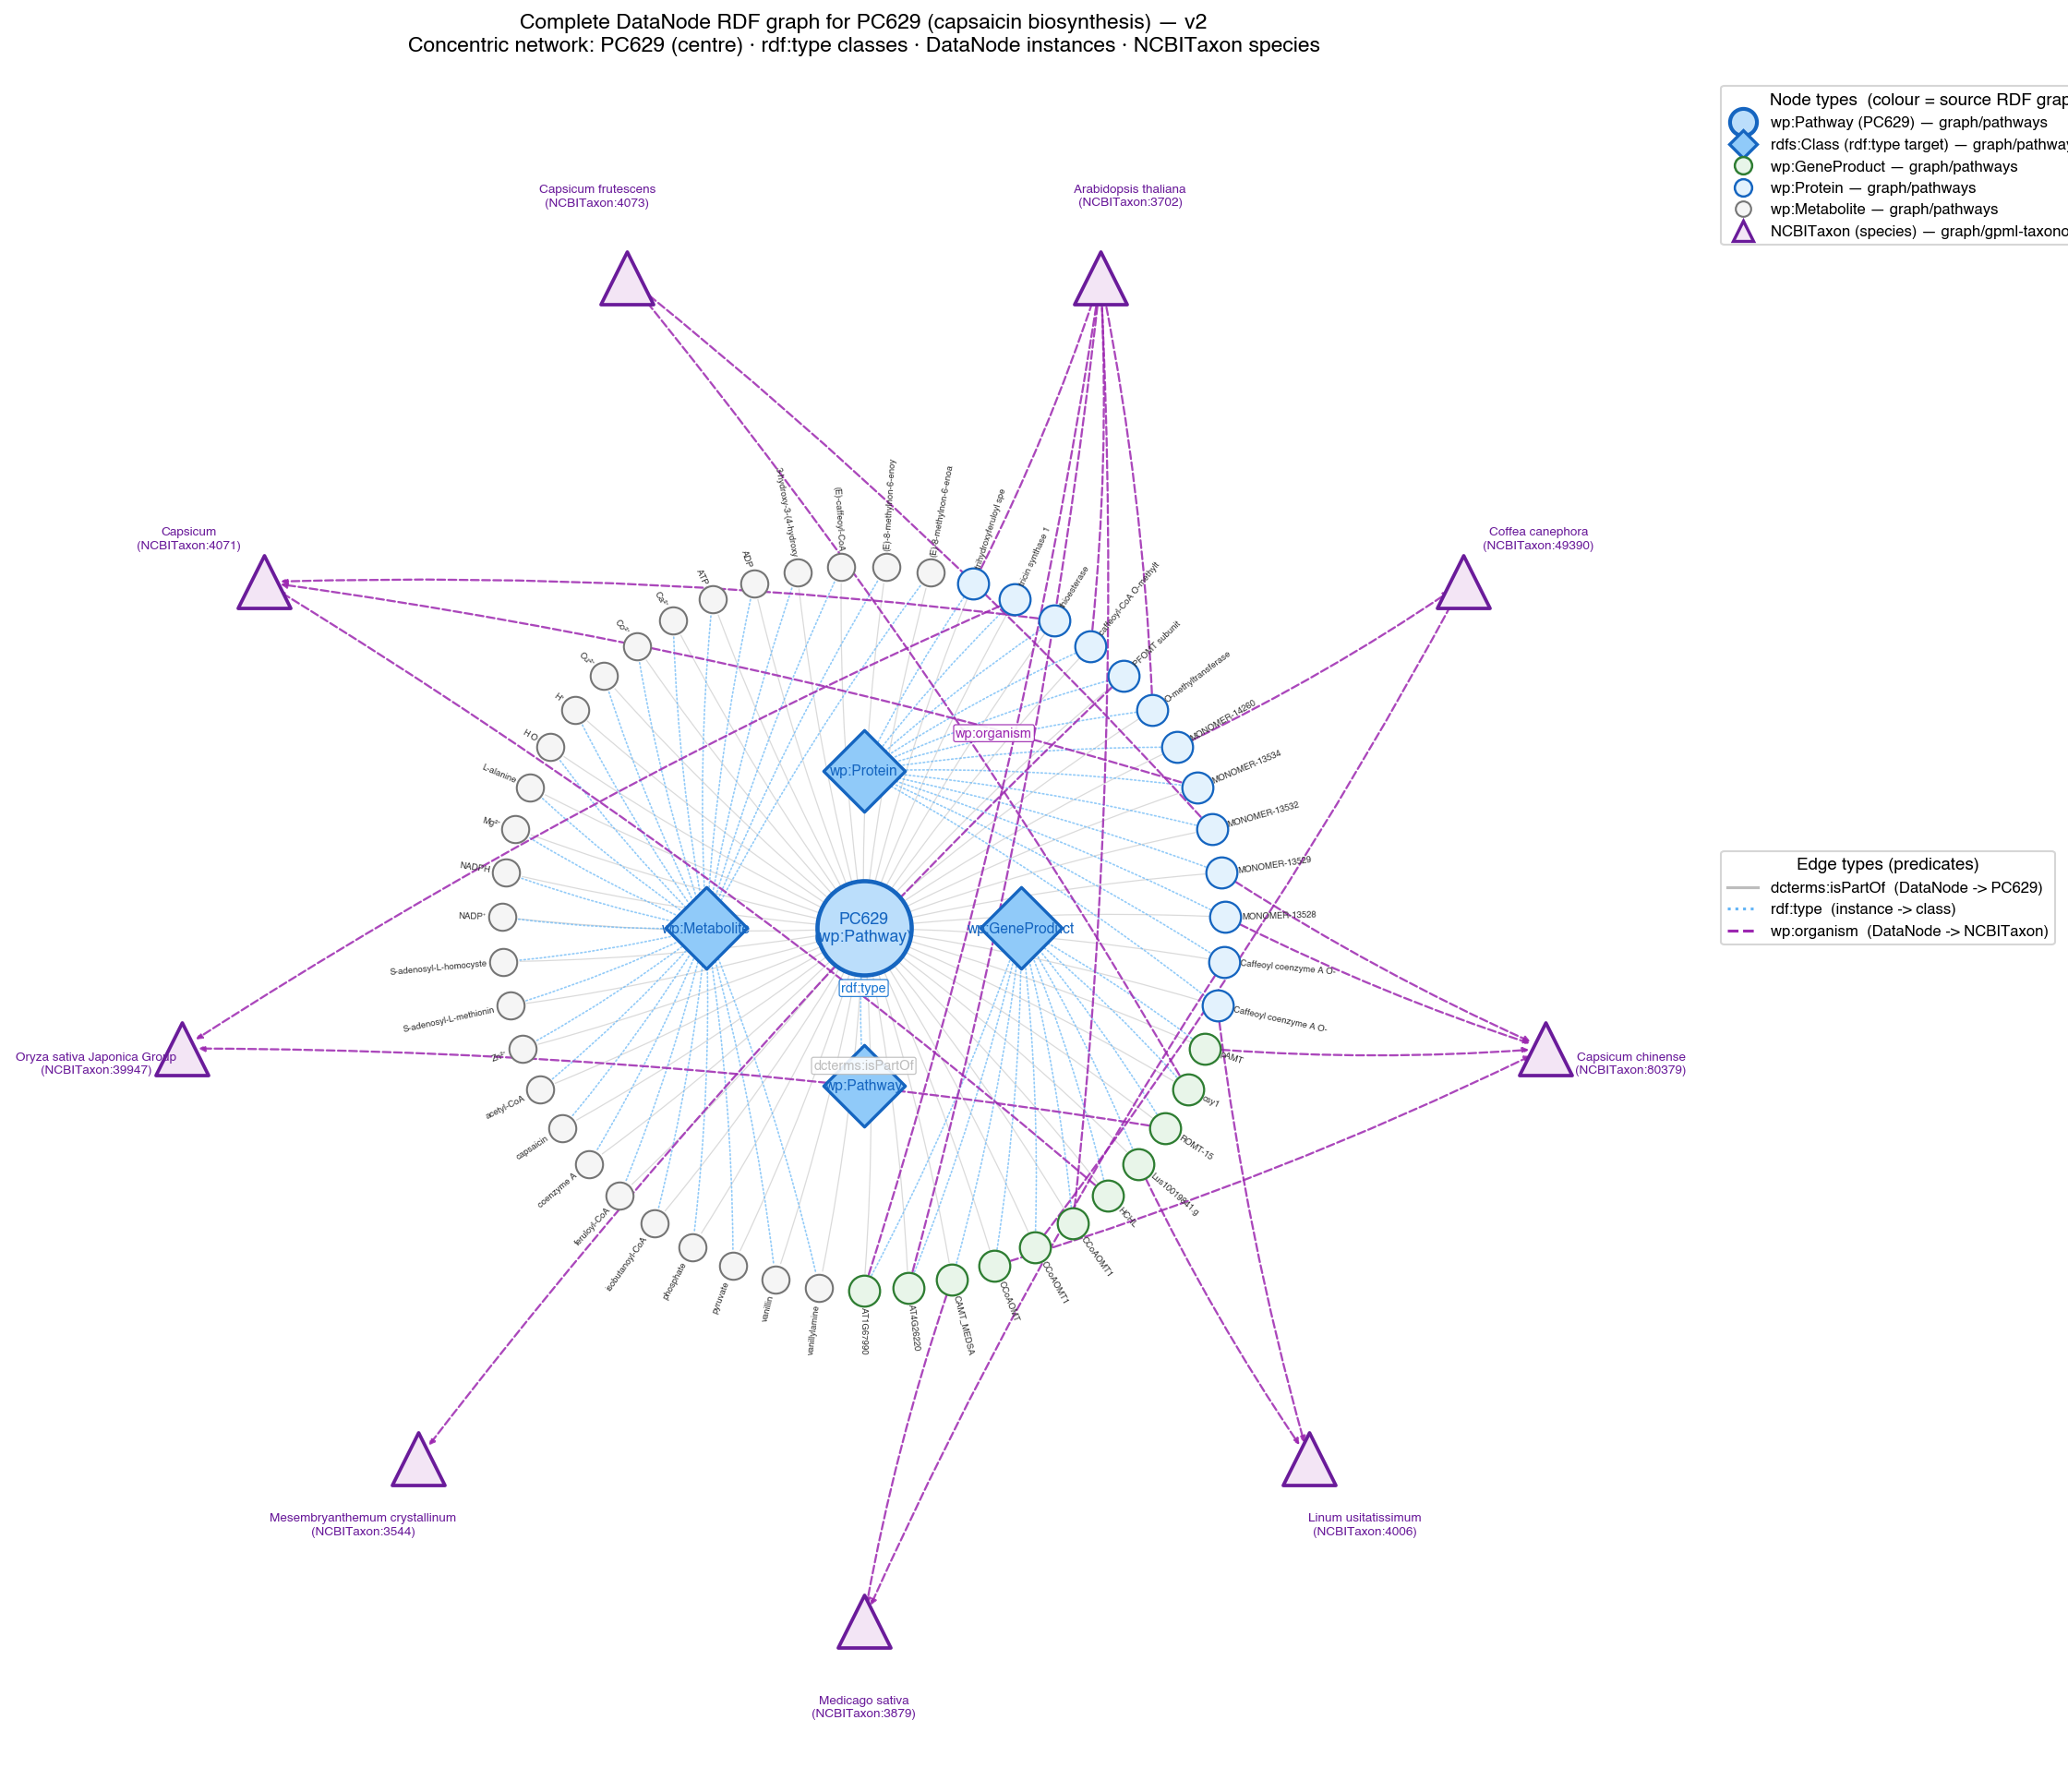

Saved: figures/output/figures/capsaicin_all_nodes_v2.{svg,pdf,png}
Saved for Cytoscape: figures/output/figures/capsaicin_all_nodes_v2.{graphml,cyjs}
  -> Cytoscape Desktop: File > Import > Network from File... (graphml recommended)
  -> Re-apply the concentric layout via Layout > Concentric Layout, using 'level'


In [15]:
import hashlib, json, pathlib
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Color palette: core (graph/pathways) vs taxonomy-extra ────────────────────
C_CORE_BD            = '#1565c0'
C_GENE_BG, C_GENE_BD = '#e8f5e9', '#2e7d32'
C_PROT_BG            = '#e3f2fd'
C_MET_BG,  C_MET_BD  = '#f5f5f5', '#757575'
C_CLASS_BG           = '#90caf9'
C_PW_BG              = '#bbdefb'
C_NCBI_BG, C_NCBI_BD = '#f3e5f5', '#6a1b9a'

E_ISPARTOF = '#bdbdbd'
E_RDFTYPE  = '#64b5f6'
E_ORGANISM = '#9c27b0'

def gv_id(iri):
    return 'n' + hashlib.md5(iri.encode()).hexdigest()[:10]

# ── Query 1: all GeneProducts/Proteins in PC629 ────────────────────────────────
nodes_all = sparql(f"""
SELECT DISTINCT ?node ?type ?label ?identifier
WHERE {{
  GRAPH <{G_PW}> {{
    ?node dcterms:isPartOf <{PW629}> ; a ?type .
    FILTER(?type IN (wp:GeneProduct, wp:Protein))
    OPTIONAL {{ ?node rdfs:label    ?label      }}
    OPTIONAL {{ ?node dc:identifier ?identifier }}
  }}
}}
ORDER BY ?type ?label
""")
nodes_all['type_short']  = nodes_all['type'].str.replace(WP, 'wp:', regex=False)
nodes_all['label_short'] = nodes_all['label'].fillna(nodes_all['identifier'].str.split('/').str[-1])

# ── Query 2: all Metabolites in PC629 ──────────────────────────────────────────
mets_all = sparql(f"""
SELECT DISTINCT ?node ?label ?identifier
WHERE {{
  GRAPH <{G_PW}> {{
    ?node dcterms:isPartOf <{PW629}> ; a wp:Metabolite .
    OPTIONAL {{ ?node rdfs:label    ?label      }}
    OPTIONAL {{ ?node dc:identifier ?identifier }}
  }}
}}
ORDER BY ?label
""")
mets_all['label_short'] = mets_all['label'].fillna(mets_all['identifier'].str.split('/').str[-1])

# ── Query 3: wp:organism (taxonomy-extra) for all DataNodes in PC629 ───────────
tax_pw = sparql(f"""
SELECT DISTINCT ?node ?taxon ?taxon_label
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node dcterms:isPartOf <{PW629}> }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?taxon_label }}
}}
""")

print(f"wp:GeneProduct/wp:Protein: {len(nodes_all)}  wp:Metabolite: {len(mets_all)}  "
      f"wp:organism edges: {len(tax_pw)}  NCBITaxon nodes: {tax_pw['taxon'].nunique()}")

# ── Build the RDF graph: every node = a resource, every edge = one triple ─────
G = nx.MultiDiGraph()

PC629_ID = gv_id(PW629)
G.add_node(PC629_ID, iri=PW629, label='PC629', rdf_type='wp:Pathway',
           category='wp:Pathway', source_graph='core')

CLASS_IRIS = {
    'wp:Pathway':     WP + 'Pathway',
    'wp:GeneProduct': WP + 'GeneProduct',
    'wp:Protein':     WP + 'Protein',
    'wp:Metabolite':  WP + 'Metabolite',
}
class_ids = {}
for name, iri in CLASS_IRIS.items():
    cid = gv_id(iri)
    class_ids[name] = cid
    G.add_node(cid, iri=iri, label=name, rdf_type='rdfs:Class',
               category='Class', source_graph='core')

G.add_edge(PC629_ID, class_ids['wp:Pathway'], predicate='rdf:type', source_graph='core')

for _, row in nodes_all.iterrows():
    nid = gv_id(row['node'])
    G.add_node(nid, iri=row['node'], label=str(row['label_short'])[:22],
               rdf_type=row['type_short'], category=row['type_short'], source_graph='core')
    G.add_edge(nid, PC629_ID, predicate='dcterms:isPartOf', source_graph='core')
    G.add_edge(nid, class_ids[row['type_short']], predicate='rdf:type', source_graph='core')

for _, row in mets_all.iterrows():
    nid = gv_id(row['node'])
    G.add_node(nid, iri=row['node'], label=str(row['label_short'])[:22],
               rdf_type='wp:Metabolite', category='wp:Metabolite', source_graph='core')
    G.add_edge(nid, PC629_ID, predicate='dcterms:isPartOf', source_graph='core')
    G.add_edge(nid, class_ids['wp:Metabolite'], predicate='rdf:type', source_graph='core')

taxon_ids = {}
for taxon, lbl in tax_pw[['taxon', 'taxon_label']].drop_duplicates().values:
    tid = gv_id(taxon)
    taxon_ids[taxon] = tid
    tnum = taxon.split('_')[-1]
    G.add_node(tid, iri=taxon, label=f'{lbl}\n(NCBITaxon:{tnum})',
               rdf_type='owl:Class', category='NCBITaxon', source_graph='taxonomy-extra')

for _, row in tax_pw.iterrows():
    G.add_edge(gv_id(row['node']), taxon_ids[row['taxon']],
               predicate='wp:organism', source_graph='taxonomy-extra')

print(f"Total nodes: {G.number_of_nodes()}  Total edges (triples): {G.number_of_edges()}")

# ── Concentric layout: PC629 (centre) -> rdf:type classes -> DataNodes -> NCBITaxon ──
def ring_positions(ring, radius, start_angle=-np.pi / 2):
    n = len(ring)
    return {node: (radius * np.cos(start_angle + 2 * np.pi * i / n),
                    radius * np.sin(start_angle + 2 * np.pi * i / n))
            for i, node in enumerate(ring)}

ring0 = [PC629_ID]
ring1 = [class_ids[k] for k in ['wp:Pathway', 'wp:GeneProduct', 'wp:Protein', 'wp:Metabolite']]
ring2 = [gv_id(n) for n in nodes_all['node']] + [gv_id(n) for n in mets_all['node']]
ring3 = list(taxon_ids.values())

pos = {PC629_ID: (0.0, 0.0)}
pos.update(ring_positions(ring1, 1.0))
pos.update(ring_positions(ring2, 2.3))

# Order the outer NCBITaxon ring by the mean angle of the DataNodes that
# annotate it, so wp:organism edges are roughly radial rather than crossing.
def angle_of(node):
    x, y = pos[node]
    return np.arctan2(y, x)

taxon_mean_angle = {}
for taxon, tid in taxon_ids.items():
    angles = [angle_of(u) for u, _ in G.in_edges(tid) if u in pos]
    taxon_mean_angle[tid] = np.arctan2(np.mean(np.sin(angles)), np.mean(np.cos(angles)))

ring3_sorted = sorted(ring3, key=lambda t: taxon_mean_angle[t])
pos.update(ring_positions(ring3_sorted, 4.4))

# ── Node & edge styles ─────────────────────────────────────────────────────────
NODE_STYLE = {
    'wp:Pathway':     dict(shape='o', fc=C_PW_BG,    ec=C_CORE_BD, size=2400, lw=2.2),
    'Class':          dict(shape='D', fc=C_CLASS_BG, ec=C_CORE_BD, size=900,  lw=1.6),
    'wp:GeneProduct': dict(shape='o', fc=C_GENE_BG,  ec=C_GENE_BD, size=260,  lw=1.1),
    'wp:Protein':     dict(shape='o', fc=C_PROT_BG,  ec=C_CORE_BD, size=260,  lw=1.1),
    'wp:Metabolite':  dict(shape='o', fc=C_MET_BG,   ec=C_MET_BD,  size=200,  lw=1.0),
    'NCBITaxon':      dict(shape='^', fc=C_NCBI_BG,  ec=C_NCBI_BD, size=750,  lw=1.8),
}
EDGE_STYLE = {
    'dcterms:isPartOf': dict(color=E_ISPARTOF, style='solid',  width=0.6, alpha=0.55),
    'rdf:type':         dict(color=E_RDFTYPE,  style='dotted', width=0.8, alpha=0.7),
    'wp:organism':      dict(color=E_ORGANISM, style='dashed', width=1.1, alpha=0.85),
}

fig, ax = plt.subplots(figsize=(15, 15))

for pred, style in EDGE_STYLE.items():
    elist = [(u, v) for u, v, k, dat in G.edges(keys=True, data=True) if dat['predicate'] == pred]
    nx.draw_networkx_edges(G, pos, edgelist=elist, ax=ax,
                            edge_color=style['color'], style=style['style'],
                            width=style['width'], alpha=style['alpha'],
                            arrows=True, arrowsize=6, arrowstyle='-|>',
                            connectionstyle='arc3,rad=0.04', node_size=300)

for cat, style in NODE_STYLE.items():
    nlist = [n for n, dat in G.nodes(data=True) if dat['category'] == cat]
    if not nlist:
        continue
    nx.draw_networkx_nodes(G, pos, nodelist=nlist, ax=ax,
                            node_shape=style['shape'], node_color=style['fc'],
                            edgecolors=style['ec'], linewidths=style['lw'],
                            node_size=style['size'])

# ── Node labels ─────────────────────────────────────────────────────────────────
for n, (x, y) in pos.items():
    dat = G.nodes[n]
    cat = dat['category']
    if cat == 'wp:Pathway':
        ax.text(x, y, dat['label'] + '\n(wp:Pathway)', ha='center', va='center',
                fontsize=8.5, fontweight='bold', color=C_CORE_BD, zorder=5)
    elif cat == 'Class':
        ax.text(x, y, dat['label'], ha='center', va='center',
                fontsize=7.5, fontweight='bold', color=C_CORE_BD, zorder=5)
    elif cat == 'NCBITaxon':
        r = np.hypot(x, y)
        ax.text(x * (r + 0.55) / r, y * (r + 0.55) / r, dat['label'],
                ha='center', va='center', fontsize=6.5, color=C_NCBI_BD,
                fontweight='bold', zorder=5)
    else:
        angle = np.degrees(np.arctan2(y, x))
        rot = angle if -90 <= angle <= 90 else angle + 180
        ax.text(x * 1.045, y * 1.045, dat['label'],
                ha='left' if -90 <= angle <= 90 else 'right', va='center',
                fontsize=4.6, rotation=rot, rotation_mode='anchor',
                color='#333333', zorder=5)

# ── Predicate names written on a representative edge of each type ──────────────
def label_edge(u, v, text, color, frac=0.5, dy=0.0):
    (x0, y0), (x1, y1) = pos[u], pos[v]
    lx, ly = x0 + (x1 - x0) * frac, y0 + (y1 - y0) * frac
    ax.text(lx, ly + dy, text, fontsize=7, color=color, ha='center', va='center',
            fontweight='bold', zorder=6,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=color, lw=0.6, alpha=0.9))

label_edge(ring2[0], PC629_ID, 'dcterms:isPartOf', E_ISPARTOF, frac=0.62)
label_edge(PC629_ID, class_ids['wp:Pathway'], 'rdf:type', '#1976d2', frac=0.5, dy=0.12)
first_org = next((u, v) for u, v, k, dat in G.edges(keys=True, data=True) if dat['predicate'] == 'wp:organism')
label_edge(first_org[0], first_org[1], 'wp:organism', E_ORGANISM, frac=0.55)

# ── Legend ("agenda") ────────────────────────────────────────────────────────────
legend_nodes = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=C_PW_BG, markeredgecolor=C_CORE_BD,
           markersize=14, markeredgewidth=2, label='wp:Pathway (PC629) — graph/pathways'),
    Line2D([0], [0], marker='D', color='none', markerfacecolor=C_CLASS_BG, markeredgecolor=C_CORE_BD,
           markersize=10, markeredgewidth=1.6, label='rdfs:Class (rdf:type target) — graph/pathways'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=C_GENE_BG, markeredgecolor=C_GENE_BD,
           markersize=9, markeredgewidth=1.2, label='wp:GeneProduct — graph/pathways'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=C_PROT_BG, markeredgecolor=C_CORE_BD,
           markersize=9, markeredgewidth=1.2, label='wp:Protein — graph/pathways'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=C_MET_BG, markeredgecolor=C_MET_BD,
           markersize=8, markeredgewidth=1.0, label='wp:Metabolite — graph/pathways'),
    Line2D([0], [0], marker='^', color='none', markerfacecolor=C_NCBI_BG, markeredgecolor=C_NCBI_BD,
           markersize=11, markeredgewidth=1.6, label='NCBITaxon (species) — graph/gpml-taxonomy-extra'),
]
legend_edges = [
    Line2D([0], [0], color=E_ISPARTOF, lw=1.5, linestyle='solid',
           label='dcterms:isPartOf  (DataNode -> PC629)'),
    Line2D([0], [0], color=E_RDFTYPE,  lw=1.5, linestyle='dotted',
           label='rdf:type  (instance -> class)'),
    Line2D([0], [0], color=E_ORGANISM, lw=1.5, linestyle='dashed',
           label='wp:organism  (DataNode -> NCBITaxon)'),
]
leg1 = ax.legend(handles=legend_nodes, title='Node types  (colour = source RDF graph)',
                  loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=8, title_fontsize=9,
                  frameon=True, borderaxespad=0.5)
ax.add_artist(leg1)
ax.legend(handles=legend_edges, title='Edge types (predicates)',
          loc='upper left', bbox_to_anchor=(1.0, 0.55), fontsize=8, title_fontsize=9,
          frameon=True, borderaxespad=0.5)

ax.set_title('Complete DataNode RDF graph for PC629 (capsaicin biosynthesis) — v2\n'
              'Concentric network: PC629 (centre) · rdf:type classes · DataNode instances · NCBITaxon species',
              fontsize=11, pad=14)
ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-5.4, 5.4)
ax.set_ylim(-5.4, 5.4)
plt.tight_layout()

# ── Save figure (SVG/PDF/PNG) ───────────────────────────────────────────────────
out_dir = pathlib.Path('figures/output/figures')
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'capsaicin_all_nodes_v2.svg', bbox_inches='tight')
fig.savefig(out_dir / 'capsaicin_all_nodes_v2.pdf', bbox_inches='tight')
fig.savefig(out_dir / 'capsaicin_all_nodes_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Cytoscape export (GraphML + Cytoscape.js JSON) ──────────────────────────────
# A 'level' attribute (0=PC629 ... 3=NCBITaxon) is included so the concentric
# layout can be recreated in Cytoscape via Layout > Concentric Layout (use
# 'level', lower values = more central). Node/edge attributes (category,
# source_graph, predicate, rdf_type) can be mapped to Style properties.
level_of = {n: r for r, ring in enumerate([ring0, ring1, ring2, ring3_sorted]) for n in ring}
H = nx.MultiDiGraph()
for n, dat in G.nodes(data=True):
    x, y = pos[n]
    H.add_node(n, **dat, level=level_of[n], x=float(x) * 100, y=float(y) * 100)
for u, v, k, dat in G.edges(keys=True, data=True):
    H.add_edge(u, v, **dat)

graphml_path = out_dir / 'capsaicin_all_nodes_v2.graphml'
nx.write_graphml(H, graphml_path)

cy = nx.cytoscape_data(H)
for el in cy['elements']['nodes']:
    nid = el['data']['id']
    x, y = pos[nid]
    el['position'] = {'x': float(x) * 100, 'y': float(y) * 100}
cyjs_path = out_dir / 'capsaicin_all_nodes_v2.cyjs'
with open(cyjs_path, 'w') as fh:
    json.dump(cy, fh, indent=2)

print(f"Saved: {out_dir}/capsaicin_all_nodes_v2.{{svg,pdf,png}}")
print(f"Saved for Cytoscape: {out_dir}/capsaicin_all_nodes_v2.{{graphml,cyjs}}")
print("  -> Cytoscape Desktop: File > Import > Network from File... (graphml recommended)")
print("  -> Re-apply the concentric layout via Layout > Concentric Layout, using 'level'")


**Figure: Complete DataNode RDF graph for PC629 — concentric network (v2).**
Every node is an individual RDF resource and every edge an individual triple (no
clustering/grouping, since "cluster" is not an RDF group type in this vocabulary).
PC629 (`wp:Pathway`, large blue circle) sits at the centre; the first ring holds the four
`rdfs:Class` nodes reached via `rdf:type` (`wp:Pathway`, `wp:GeneProduct`, `wp:Protein`,
`wp:Metabolite`); the second ring holds all 51 DataNode instances (11 `wp:GeneProduct`,
13 `wp:Protein`, 27 `wp:Metabolite`), each linked to PC629 via `dcterms:isPartOf` and to
its class via `rdf:type`; the outer ring holds the 9 `NCBITaxon` species reached via
`wp:organism`. Node fill colour distinguishes the **source named graph**: blue/green
shades for `graph/pathways` (core WikiPathways RDF) vs. purple for
`graph/gpml-taxonomy-extra` (species annotations); node shape distinguishes RDF type
(circle = DataNode instance, diamond = `rdfs:Class`, triangle = `NCBITaxon`). Edge colour
and style distinguish the three predicates (`dcterms:isPartOf`, `rdf:type`,
`wp:organism`), each labelled directly on a representative edge. The full node-type and
edge-type legend ("agenda") is shown to the right of the figure.

**Cytoscape export:** `capsaicin_all_nodes_v2.graphml` and `capsaicin_all_nodes_v2.cyjs`
(in `figures/output/figures/`) contain the same 65-node / 127-edge graph, including the
`category`, `source_graph`, `rdf_type`, `predicate`, and `level` attributes used above, so
the figure can be re-styled, re-laid-out, or further annotated in
[Cytoscape Desktop](https://cytoscape.org/).